In [57]:
# ====================
# CAPSTONE PROJECT EDA
# ====================

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

# Add project root to path to use methods from src.utils
sys.path.append(os.path.abspath(".."))
from src.utils import *

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            classification_report)

# Feature importance & explainability
# import shap

# Settings
# pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

print("Environment ready! ✓")

Environment ready! ✓


In [58]:
# =======================
# STEP 1: PROBLEM FRAMING
# =======================

# Document your problem statement here
PROBLEM_STATEMENT = """
BUSINESS PROBLEM:
[Air pollution is a growing global challenge with severe consequences for public health and economic sustainability. 
According to the World Health Organization (WHO), air pollution is responsible for millions of premature deaths each year 
and is a major risk factor for lung diseases such as asthma, chronic obstructive pulmonary disease (COPD), lung cancer and 
respiratory infections. The WHO recommends strict limits on pollutants like fine particulate matter, nitrogen dioxide (NO₂) 
and ozone, emphasizing that reducing air pollution is one of the most effective ways to prevent non-communicable diseases 
and lower healthcare burdens.

Analyzing and understanding daily air quality data can play a crucial role in addressing these challenges. To do so, it is 
essential to identify which factors — such as temperature, humidity, time of day, and seasonal patterns — influence air quality 
levels.
By gaining these insights, actionable recommendations can be provided to the public to reduce exposure to harmful pollutants. 
For example, guidance can be given on when to avoid leaving the house or which times of day are safest for outdoor physical 
activities such as exercise.
In addition, weather forecasts combined with air quality predictions can be used proactively by authorities to manage traffic 
and industrial activity before pollution levels rise too high and exceed WHO-recommended thresholds. This preventive approach 
can help protect public health while reducing long-term healthcare costs.]

ML TASK TYPES:
[Classification / Regression / Clustering / Anomaly Detection / Recommendation]

SUCCESS METRICS:
- Technical: [Accuracy > 0.75, F1 > 0.75]
- Business: [Provide recommendations to the public on whether it is safe to leave the house:
	YES (Green)     -> Safe to go outside
	AVOID (Yellow)  -> Limit outdoor activities
	DANGER (Red)    -> Stay indoors, WHO-recommended threshold was exceeded

TARGET VARIABLE:
[Air pollution levels exceeded the WHO-recommended threshold for this toxin]
"""

print(PROBLEM_STATEMENT)


BUSINESS PROBLEM:
[Air pollution is a growing global challenge with severe consequences for public health and economic sustainability. 
According to the World Health Organization (WHO), air pollution is responsible for millions of premature deaths each year 
and is a major risk factor for lung diseases such as asthma, chronic obstructive pulmonary disease (COPD), lung cancer and 
respiratory infections. The WHO recommends strict limits on pollutants like fine particulate matter, nitrogen dioxide (NO₂) 
and ozone, emphasizing that reducing air pollution is one of the most effective ways to prevent non-communicable diseases 
and lower healthcare burdens.

Analyzing and understanding daily air quality data can play a crucial role in addressing these challenges. To do so, it is 
essential to identify which factors — such as temperature, humidity, time of day, and seasonal patterns — influence air quality 
levels.
By gaining these insights, actionable recommendations can be provided to the

In [ ]:
# ==========================================
# STEP 2: DATA LOADING & INITIAL EXPLORATION
# ==========================================

# Load your dataset
df: pd.DataFrame = pd.read_csv('../data/AirQualityUCI.csv', delimiter=';')

# Thresholds for each toxin by 'WHO Air Quality Guidlines (AQG)' or 'European Environment Agency (EEA)' - 'None' if no threshold is defined yet
# Source of comment behind each toxin: https://archive.ics.uci.edu/dataset/360/air+quality
thresholds: dict = {
    'CO(GT)': 4,            # True hourly averaged concentration CO in mg/m^3                                   - WHO AQG page: 134
    'NMHC(GT)': None,       # True hourly averaged overall Non Metanic HydroCarbons concentration in microg/m^3 - No threshold defined yet
    'C6H6(GT)': 5,          # True hourly averaged Benzene concentration in microg/m^3                          - EEA homepage
    'NOx(GT)': None,        # True hourly averaged NOx concentration in ppb                                     - No threshold defined yet
    'NO2(GT)': 10,          # True hourly averaged NO2 concentration in microg/m^3                              - WHO AQG page: 116
    'PT08.S5(O3) ': 60      # Hourly averaged sensor response (nominally O3 targeted)                           - WHO AQG page: 136
}

# Quick overview
def data_overview(df):
    """Print comprehensive data overview."""
    print("="*60)
    print("DATASET OVERVIEW")
    print("="*60)
    print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"\nColumn Types:\n{df.dtypes.value_counts()}")
    print(f"\nMissing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"\nFirst 5 Rows:")
    display(df.head())

# Print results:
# data_overview(df) # Shape: 9471 rows × 17 columns (two unnamed colums with no data)

# Drop columns using regex in filter
df = df.drop(df.filter(regex="Unnamed").columns, axis=1)

# Check rows with no data
rows_to_drop: list = []
is_nan: tuple[np.ndarray, np.ndarray] = np.where(pd.isnull(df)) # tuple[np.ndarray -> indices of column, np.ndarray -> indices of rows]
for i_row, i_col in zip(is_nan[0], is_nan[1]):
    # print(f'Row: {i_row}, Column: {i_col}, Value: {df.iloc[i_row, i_col]}')
    if i_row not in rows_to_drop:
        rows_to_drop.append(i_row) # rows with no data in csv-file

# Drop rows with NaN
df = df.drop(index=rows_to_drop)
# data_overview(df) # Shape: 9357 rows × 15 columns => NO missing values!

In [60]:
# =====================================
# STEP 3: DATA CLEANING and PREPARATION
# =====================================

# Analyze columns: 'Date' and 'Time'
''' 
    1. Found no missing values 
    2. Converting dtype 'object' to dtype 'DateTime' by merging both
    3. Creating new column: 'DateTime'
'''
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df['DateTime'].head()

0   2004-03-10 18:00:00
1   2004-03-10 19:00:00
2   2004-03-10 20:00:00
3   2004-03-10 21:00:00
4   2004-03-10 22:00:00
Name: DateTime, dtype: datetime64[ns]

# Column name: CO(GT)
Types found (CO(GT)): object
Types found (CO(GT)_to_float): float64
Neg. values (CO(GT)_to_float): 1683


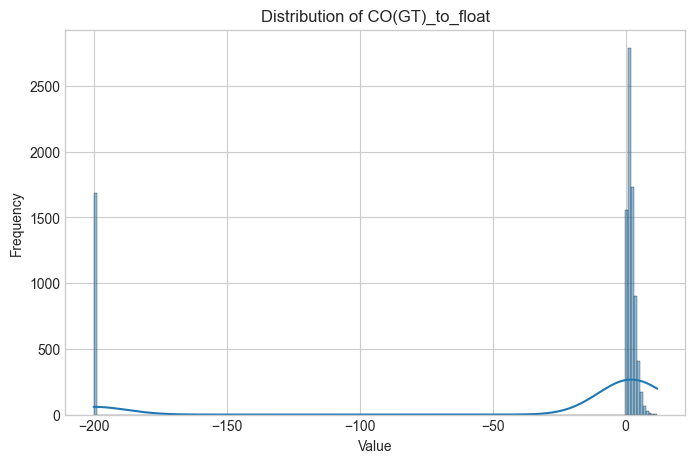

# Column name: CO(GT)
Types found (CO(GT)): float64
Neg. values (CO(GT)): 0


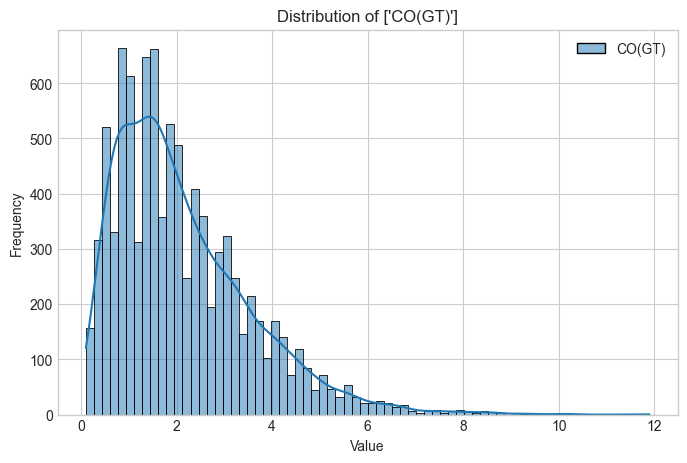

In [61]:
# Analyze column: 'CO(GT)'
analyze_col(df=df, col_name='CO(GT)', convert_dtype_to_float=True)
''' 
    1. Found 1,683 negative values after dtype 'object' was converted to 'float'
    2. All negatives have the same value of -200 (error code)
'''
# Replace each '-200' with NaN and interpolate the missing value(s)
df['CO(GT)_to_float'] = df['CO(GT)'].str.replace(',', '.', regex=False).astype(float) # 0,4 -> 0.4 
df['CO(GT)_to_float'] = df['CO(GT)_to_float'].replace(-200, np.nan)
df['CO(GT)'] = df['CO(GT)_to_float']
df['CO(GT)'] = df['CO(GT)'].interpolate(method='linear', limit_direction='both')
analyze_col(df=df, col_name='CO(GT)', convert_dtype_to_float=False)

# Column name: PT08.S1(CO)
Types found (PT08.S1(CO)): float64
Neg. values (PT08.S1(CO)): 366


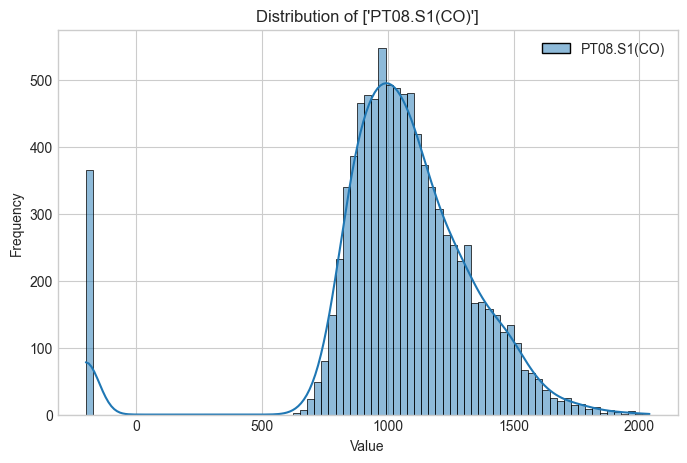

# Column name: PT08.S1(CO)
Types found (PT08.S1(CO)): float64
Neg. values (PT08.S1(CO)): 0


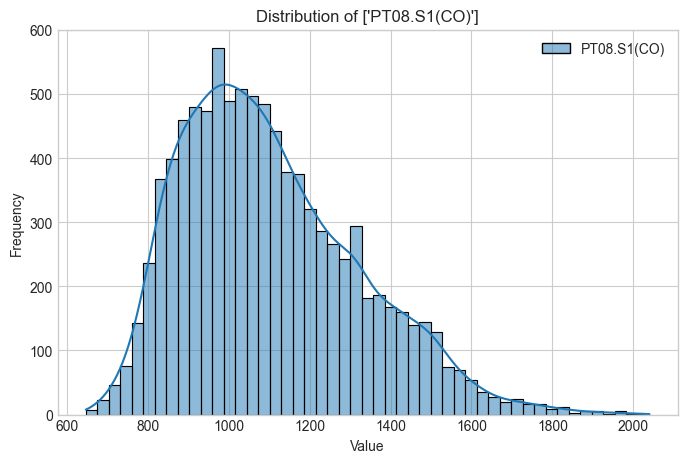

In [62]:
# Analyze column: 'PT08.S1(CO)'
analyze_col(df=df, col_name='PT08.S1(CO)', convert_dtype_to_float=False)
# df.loc[df['PT08.S1(CO)'] < 0, 'PT08.S1(CO)']
''' 
    1. Found 366 negative values of dtype 'float'
    2. All negatives have the same value of -200 (error code)
'''

# Replace each '-200' with NaN and interpolate the missing value(s)
df['PT08.S1(CO)'] = df['PT08.S1(CO)'].replace(-200, np.nan)
df['PT08.S1(CO)'] = df['PT08.S1(CO)'].interpolate(method='linear', limit_direction='both')
analyze_col(df=df, col_name='PT08.S1(CO)', convert_dtype_to_float=False)

# Column name: NMHC(GT)
Types found (NMHC(GT)): float64
Neg. values (NMHC(GT)): 8443


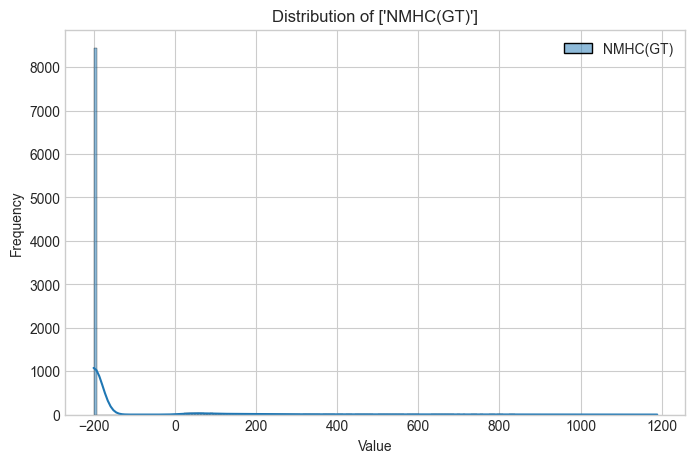

" \n    1. Found 8,443 negative values of dtype 'float'\n    2. All negatives have the same value of -200 (error code)\n    3. Column will be EXCLUDED because more than 90% of the values are missing (8,443/9,357)\n"

In [63]:
# Analyze column: 'NMHC(GT)'
analyze_col(df=df, col_name='NMHC(GT)', convert_dtype_to_float=False)
''' 
    1. Found 8,443 negative values of dtype 'float'
    2. All negatives have the same value of -200 (error code)
    3. Column will be EXCLUDED because more than 90% of the values are missing (8,443/9,357)
'''

# Column name: C6H6(GT)
Types found (C6H6(GT)): object
Types found (C6H6(GT)_to_float): float64
Neg. values (C6H6(GT)_to_float): 366


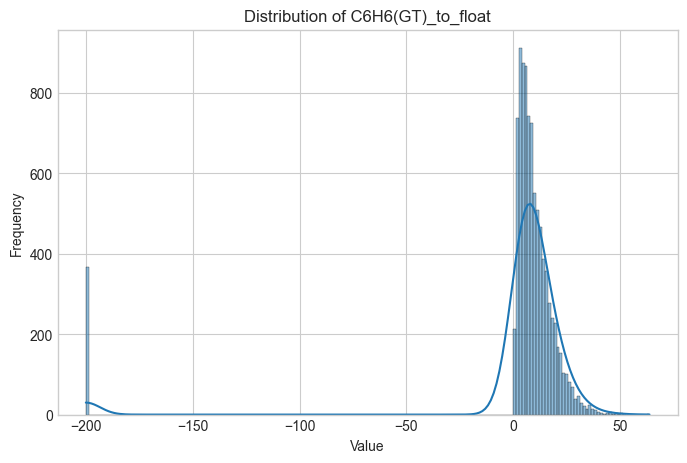

# Column name: C6H6(GT)
Types found (C6H6(GT)): float64
Neg. values (C6H6(GT)): 0


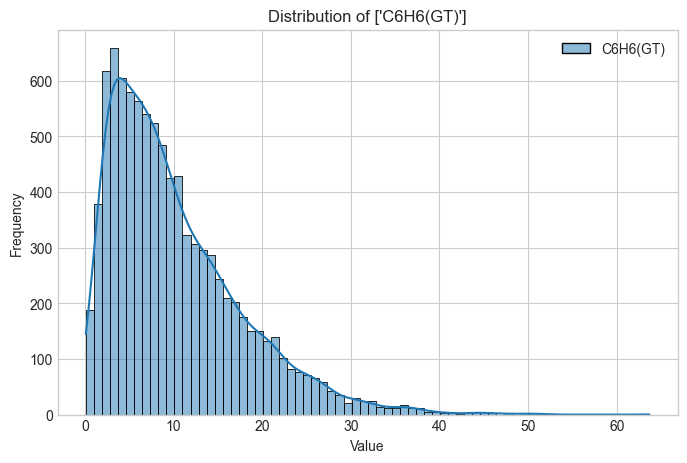

In [64]:
# Analyze column: 'C6H6(GT)'
analyze_col(df=df, col_name='C6H6(GT)', convert_dtype_to_float=True)
''' 
    1. Found 366 negative values of dtype 'float'
    2. All negatives have the same value of -200 (error code)
'''

# Replace each '-200' with NaN and interpolate the missing value(s)
df['C6H6(GT)_to_float'] = df['C6H6(GT)'].str.replace(',', '.', regex=False).astype(float) # 0,4 -> 0.4 
df['C6H6(GT)_to_float'] = df['C6H6(GT)_to_float'].replace(-200, np.nan)
df['C6H6(GT)'] = df['C6H6(GT)_to_float']
df['C6H6(GT)'] = df['C6H6(GT)'].interpolate(method='linear', limit_direction='both')
analyze_col(df=df, col_name='C6H6(GT)', convert_dtype_to_float=False)

# Column name: PT08.S2(NMHC)
Types found (PT08.S2(NMHC)): float64
Neg. values (PT08.S2(NMHC)): 366


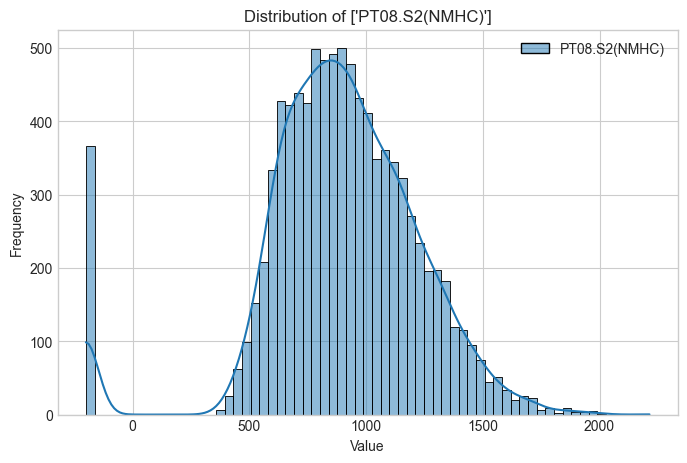

# Column name: PT08.S2(NMHC)
Types found (PT08.S2(NMHC)): float64
Neg. values (PT08.S2(NMHC)): 0


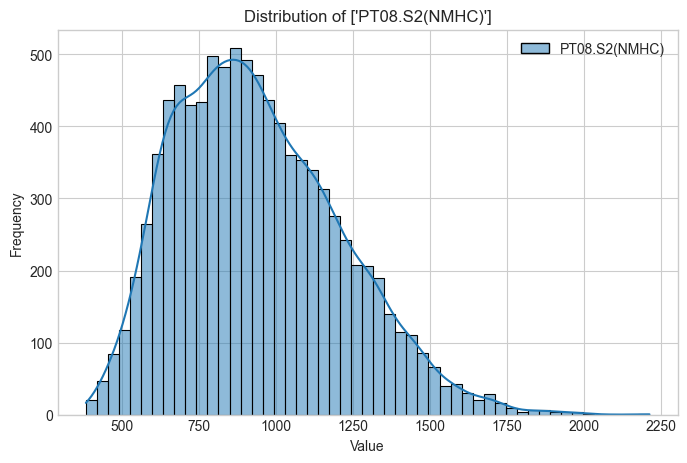

In [65]:
# Analyze column: 'PT08.S2(NMHC)'
analyze_col(df=df, col_name='PT08.S2(NMHC)', convert_dtype_to_float=False)
''' 
    1. Found 366 negative values of dtype 'float'
    2. All negatives have the same value of -200 (error code)
'''

# Replace each '-200' with NaN and interpolate the missing value(s)
df['PT08.S2(NMHC)'] = df['PT08.S2(NMHC)'].replace(-200, np.nan)
df['PT08.S2(NMHC)'] = df['PT08.S2(NMHC)'].interpolate(method='linear', limit_direction='both')
analyze_col(df=df, col_name='PT08.S2(NMHC)', convert_dtype_to_float=False)

# Column name: NOx(GT)
Types found (NOx(GT)): float64
Neg. values (NOx(GT)): 1639


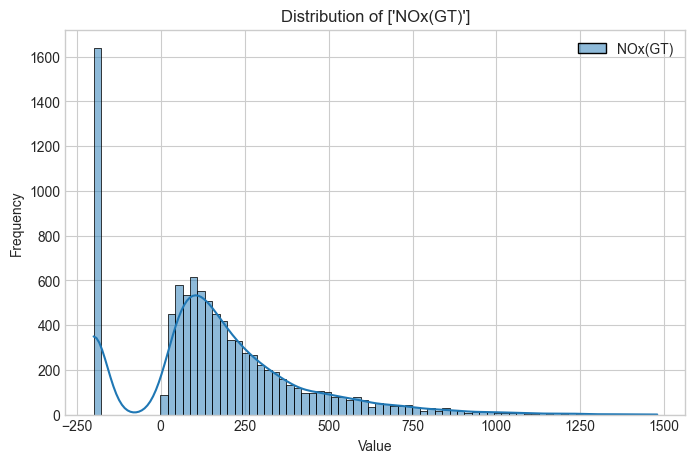

# Column name: NOx(GT)
Types found (NOx(GT)): float64
Neg. values (NOx(GT)): 0


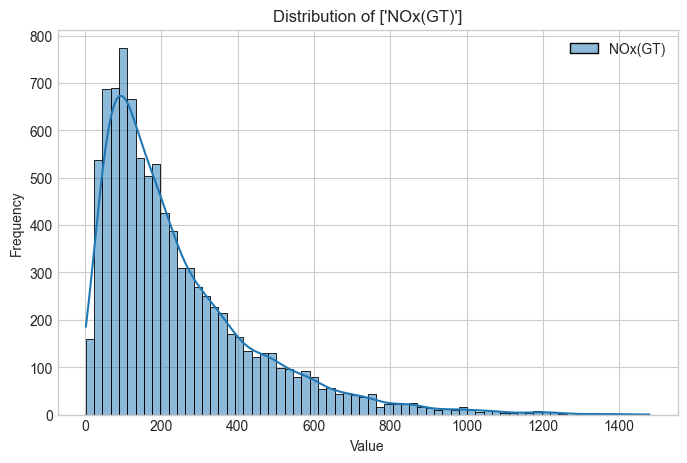

In [66]:
# Analyze column: 'NOx(GT)'
analyze_col(df=df, col_name='NOx(GT)', convert_dtype_to_float=False)
''' 
    1. Found 1,639 negative values of dtype 'float'
    2. All negatives have the same value of -200 (error code)
'''

# Replace each '-200' with NaN and interpolate the missing value(s)
df['NOx(GT)'] = df['NOx(GT)'].replace(-200, np.nan)
df['NOx(GT)'] = df['NOx(GT)'].interpolate(method='linear', limit_direction='both')
analyze_col(df=df, col_name='NOx(GT)', convert_dtype_to_float=False)

# Column name: PT08.S3(NOx)
Types found (PT08.S3(NOx)): float64
Neg. values (PT08.S3(NOx)): 366


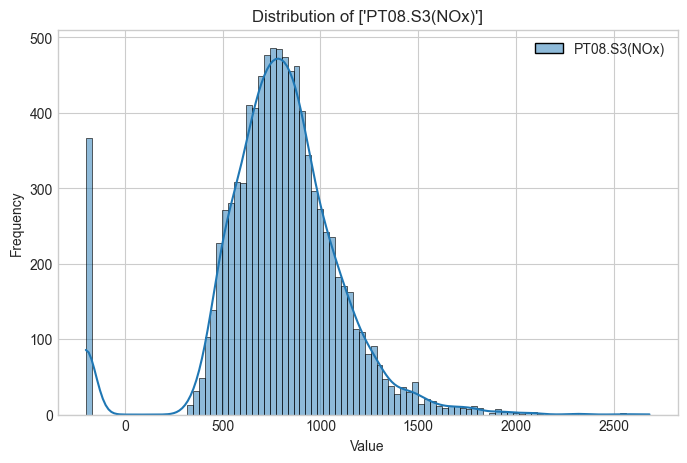

# Column name: PT08.S3(NOx)
Types found (PT08.S3(NOx)): float64
Neg. values (PT08.S3(NOx)): 0


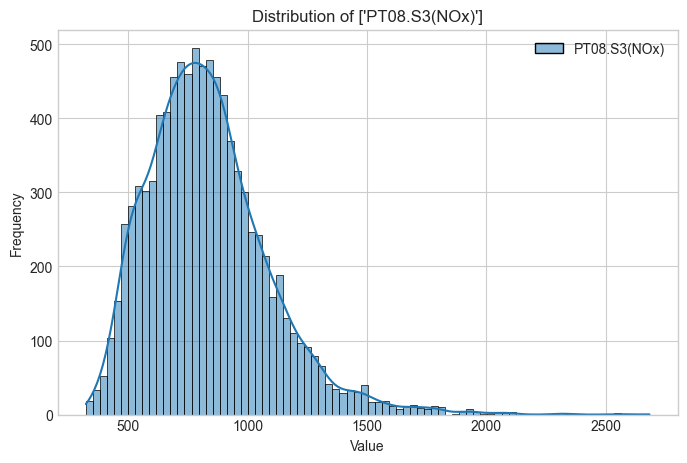

In [67]:
# Analyze column: 'PT08.S3(NOx)'
analyze_col(df=df, col_name='PT08.S3(NOx)', convert_dtype_to_float=False)
''' 
    1. Found 366 negative values of dtype 'float'
    2. All negatives have the same value of -200 (error code)
'''

# Replace each '-200' with NaN and interpolate the missing value(s)
df['PT08.S3(NOx)'] = df['PT08.S3(NOx)'].replace(-200, np.nan)
df['PT08.S3(NOx)'] = df['PT08.S3(NOx)'].interpolate(method='linear', limit_direction='both')
analyze_col(df=df, col_name='PT08.S3(NOx)', convert_dtype_to_float=False)

# Column name: NO2(GT)
Types found (NO2(GT)): float64
Neg. values (NO2(GT)): 1642


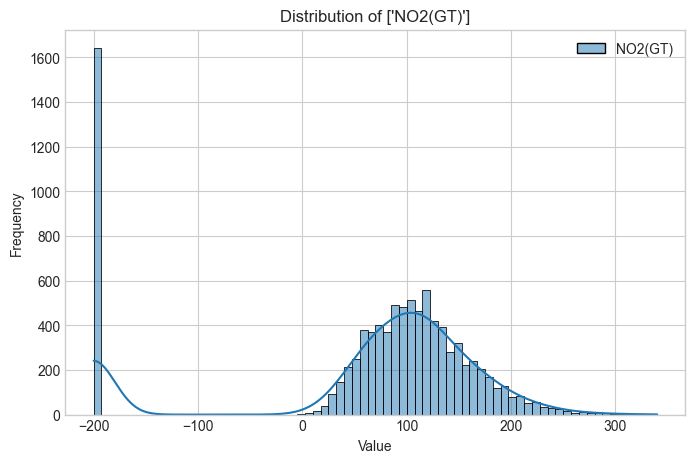

# Column name: NO2(GT)
Types found (NO2(GT)): float64
Neg. values (NO2(GT)): 0


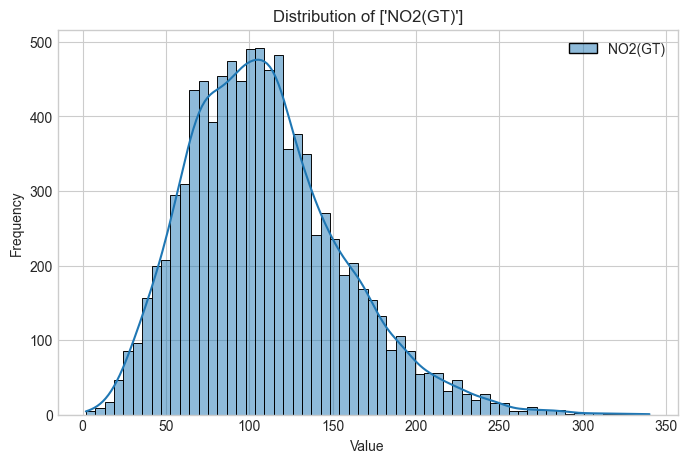

In [68]:
# Analyze column: 'NO2(GT)'
analyze_col(df=df, col_name='NO2(GT)', convert_dtype_to_float=False)
''' 
    1. Found 1,642 negative values of dtype 'float'
    2. All negatives have the same value of -200 (error code)
'''

# Replace each '-200' with NaN and interpolate the missing value(s)
df['NO2(GT)'] = df['NO2(GT)'].replace(-200, np.nan)
df['NO2(GT)'] = df['NO2(GT)'].interpolate(method='linear', limit_direction='both')
analyze_col(df=df, col_name='NO2(GT)', convert_dtype_to_float=False)

# Column name: PT08.S4(NO2)
Types found (PT08.S4(NO2)): float64
Neg. values (PT08.S4(NO2)): 366


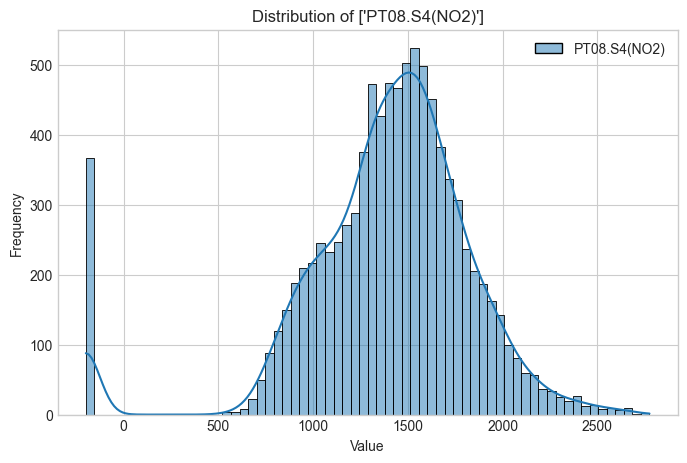

# Column name: PT08.S4(NO2)
Types found (PT08.S4(NO2)): float64
Neg. values (PT08.S4(NO2)): 0


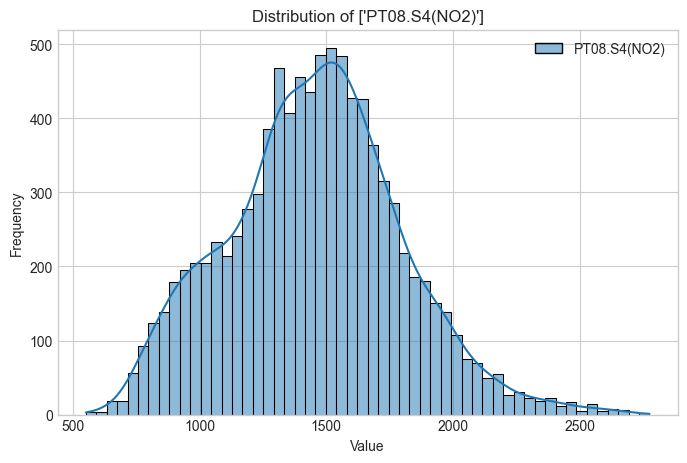

In [69]:
# Analyze column: 'PT08.S4(NO2)'
analyze_col(df=df, col_name='PT08.S4(NO2)', convert_dtype_to_float=False)
''' 
    1. Found 366 negative values of dtype 'float'
    2. All negatives have the same value of -200 (error code)
'''

# Replace each '-200' with NaN and interpolate the missing value(s)
df['PT08.S4(NO2)'] = df['PT08.S4(NO2)'].replace(-200, np.nan)
df['PT08.S4(NO2)'] = df['PT08.S4(NO2)'].interpolate(method='linear', limit_direction='both')
analyze_col(df=df, col_name='PT08.S4(NO2)', convert_dtype_to_float=False)

# Column name: PT08.S5(O3)
Types found (PT08.S5(O3)): float64
Neg. values (PT08.S5(O3)): 366


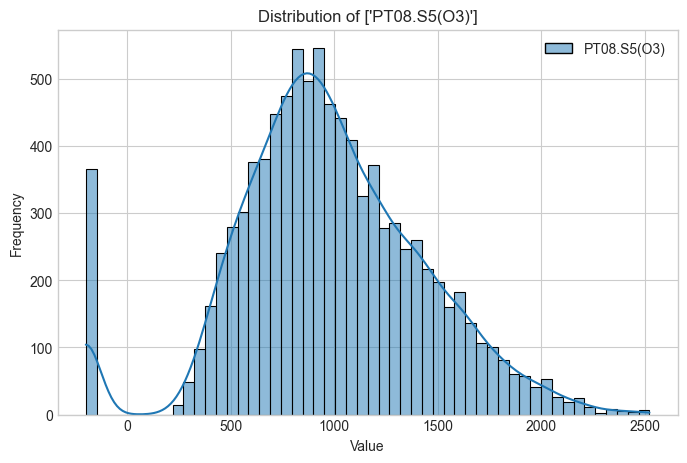

# Column name: PT08.S5(O3)
Types found (PT08.S5(O3)): float64
Neg. values (PT08.S5(O3)): 0


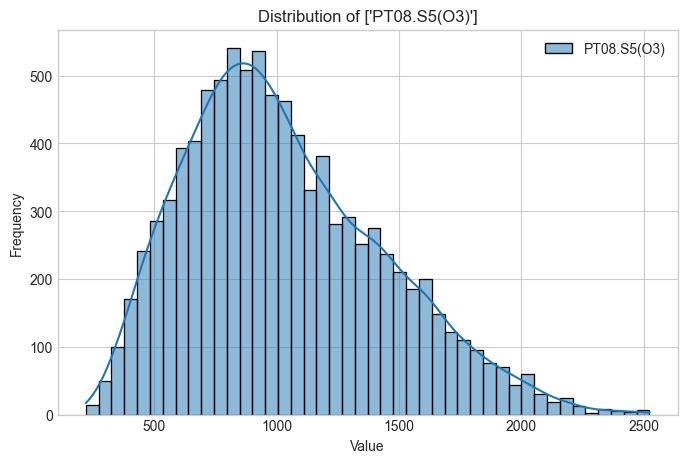

In [70]:
# Analyze column: 'PT08.S5(O3)'
analyze_col(df=df, col_name='PT08.S5(O3)', convert_dtype_to_float=False)
''' 
    1. Found 366 negative values of dtype 'float'
    2. All negatives have the same value of -200 (error code)
'''

# Replace each '-200' with NaN and interpolate the missing value(s)
df['PT08.S5(O3)'] = df['PT08.S5(O3)'].replace(-200, np.nan)
df['PT08.S5(O3)'] = df['PT08.S5(O3)'].interpolate(method='linear', limit_direction='both')
analyze_col(df=df, col_name='PT08.S5(O3)', convert_dtype_to_float=False)

# Column name: T
Types found (T): object
Types found (T_to_float): float64
Neg. values (T_to_float): 379


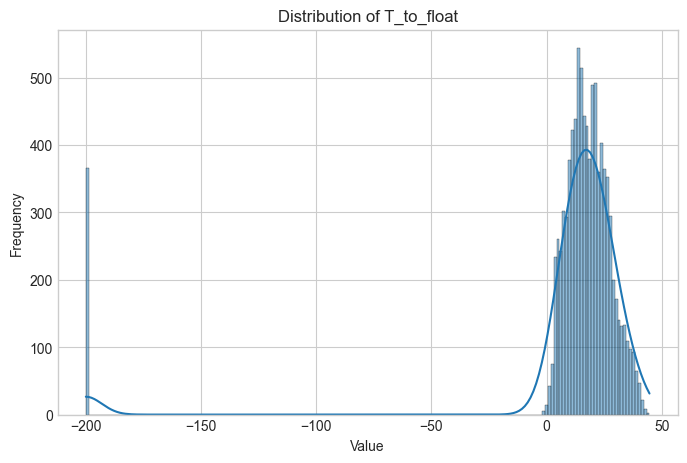

# Column name: T
Types found (T): float64
Neg. values (T): 13


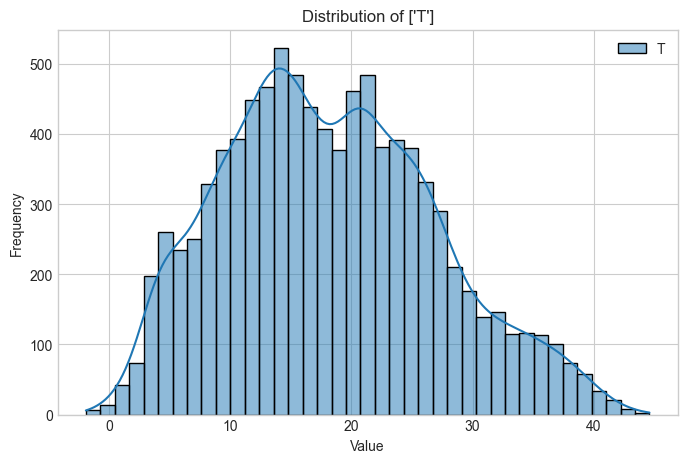

In [71]:
# Analyze column: 'T' (Temperature)
analyze_col(df=df, col_name='T', convert_dtype_to_float=True)
''' 
    1. Found 379 negative values of dtype 'float'
    2. Most negatives have the same value of -200 (error code)
    3. 13/379 negatives are 'real' temperatures in Celcius
'''

# Replace each '-200' with NaN and interpolate the missing value(s)
df['T_to_float'] = df['T'].str.replace(',', '.', regex=False).astype(float) # 0,4 -> 0.4 
df['T_to_float'] = df['T_to_float'].replace(-200, np.nan)
df['T'] = df['T_to_float']
df['T'] = df['T'].interpolate(method='linear', limit_direction='both')
analyze_col(df=df, col_name='T', convert_dtype_to_float=False)

# Column name: RH
Types found (RH): object
Types found (RH_to_float): float64
Neg. values (RH_to_float): 366


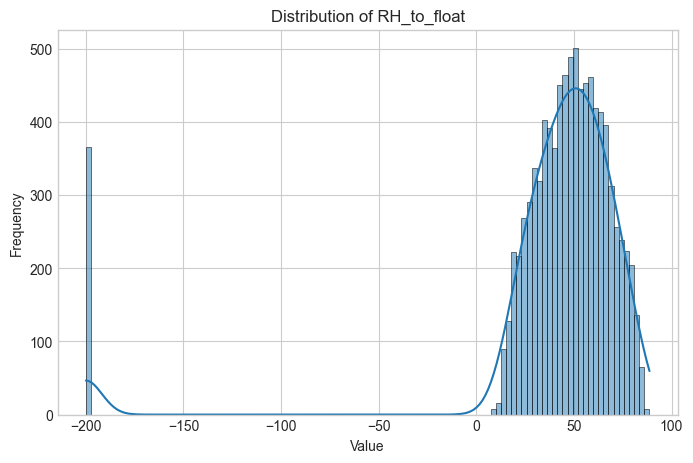

# Column name: RH
Types found (RH): float64
Neg. values (RH): 0


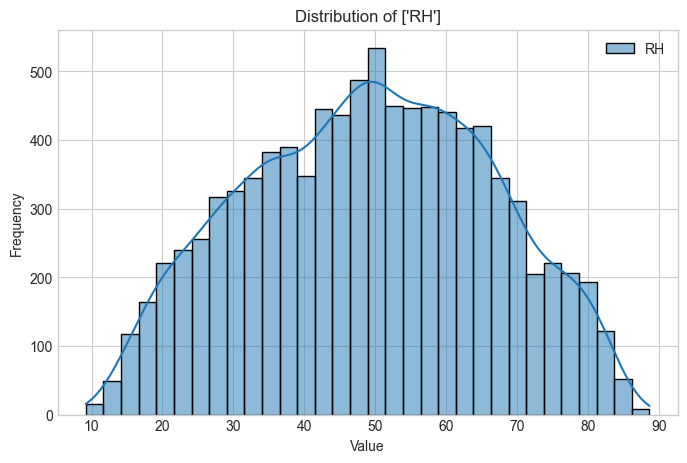

In [72]:
# Analyze column: 'RH' (Rel. Humidity)
analyze_col(df=df, col_name='RH', convert_dtype_to_float=True)
''' 
    1. Found 366 negative values of dtype 'float'
    2. All negatives have the same value of -200 (error code)
'''

# Replace each '-200' with NaN and interpolate the missing value(s)
df['RH_to_float'] = df['RH'].str.replace(',', '.', regex=False).astype(float) # 0,4 -> 0.4 
df['RH_to_float'] = df['RH_to_float'].replace(-200, np.nan)
df['RH'] = df['RH_to_float']
df['RH'] = df['RH'].interpolate(method='linear', limit_direction='both')
analyze_col(df=df, col_name='RH', convert_dtype_to_float=False)

# Column name: AH
Types found (AH): object
Types found (AH_to_float): float64
Neg. values (AH_to_float): 366


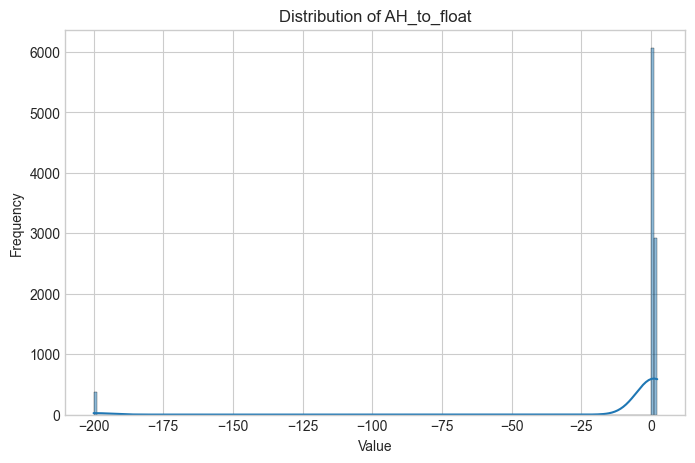

# Column name: AH
Types found (AH): float64
Neg. values (AH): 0


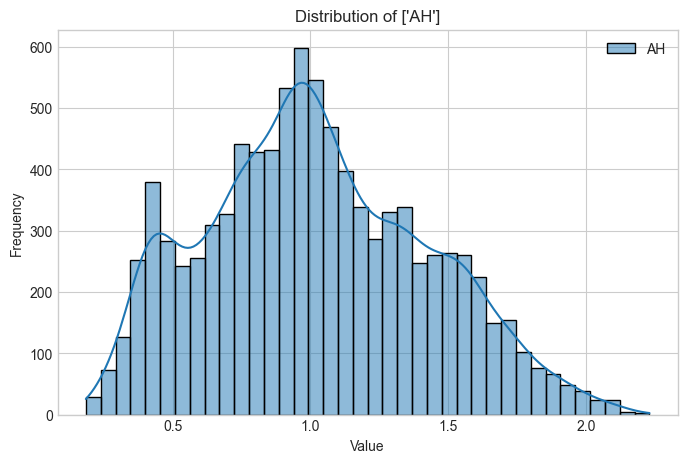

In [73]:
# Analyze column: 'AH' (Abs. Humidity)
analyze_col(df=df, col_name='AH', convert_dtype_to_float=True)
''' 
    1. Found 366 negative values of dtype 'float'
    2. All negatives have the same value of -200 (error code)
'''

# Replace each '-200' with NaN and interpolate the missing value(s)
df['AH_to_float'] = df['AH'].str.replace(',', '.', regex=False).astype(float) # 0,4 -> 0.4 
df['AH_to_float'] = df['AH_to_float'].replace(-200, np.nan)
df['AH'] = df['AH_to_float']
df['AH'] = df['AH'].interpolate(method='linear', limit_direction='both')
analyze_col(df=df, col_name='AH', convert_dtype_to_float=False)

In [74]:
# Save cleaned data to file (pickle)
df.to_pickle('../data/AirQualityUCICleaned.pkl')